# 📋 INSTRUCTOR NOTEBOOK — Time-Aware Evaluation and Forecasting Baselines

**Module 0 · Lesson 7 of 13 · Instructor edition**  
**Estimated class time:** 75–90 minutes  
**Source sequence:** Original Day 3  

**Prerequisite:** Lesson 6  

> **Do not distribute to students.** This edition contains solutions, teaching notes, and model answers.

## Learning objectives

By the end of this lesson, you should be able to:

- Create a chronological train/test split without leakage.
- Implement a naive last-value forecast.
- Fit an AR baseline using training data only.

---
## 🎯 SLOs for Today

> **SLO 4:** Implement and evaluate multiple forecasting models (naive baseline, AR,
> tree-based model, MLP, RNN, and LSTM) using time-aware train/test splits.
>
> **SLO 5:** Quantitatively compare forecasting performance using appropriate error metrics
> (e.g., RMSE, MAE) and interpret differences across models.
>
> **SLO 6:** Explain the role of hidden state, recurrence, and gating mechanisms in RNNs
> and LSTMs, and describe how they extend linear memory models.

**By end of day, students should be able to:**
- Explain why random shuffling is forbidden in time series train/test splits
- Implement a naive last-value baseline and explain its importance
- Re-use the lag matrix from Day 2 to feed tree-based and MLP models
- Compute and interpret RMSE and MAE, choosing between them appropriately
- Describe the recurrence equation of an RNN and identify the hidden state
- Explain what a gate does in an LSTM and why it solves the vanishing gradient problem
- Build a comparison table of all six model families and interpret results

---
## 📣 Segment 0 — Recap & Imports (20 min)

### Talking Points

**Day 2 recap (5 min):** Ask students: *"What is the AR(p) model equation, and what does
the lag matrix let you do that AutoReg alone doesn't?"*
Expected answer: AR(p) uses last p values to predict next; lag matrix re-frames the problem
as supervised learning, unlocking any ML model.

**Bridge to today:** *"The lag matrix is the key. Today we plug it into six different model
families and systematically compare them. We also meet two new families — RNNs and LSTMs —
which process sequences in a fundamentally different way."*

**New imports:** `sklearn` ensemble models, `torch` for neural networks. Normalize PyTorch
as the standard deep learning library. Students don't need to know it well yet — the goal
today is intuition and basic usage.

### ⚠️ Common First-Segment Mistakes
- **Installing torch:** If students don't have it, `pip install torch` (CPU-only version
  is fine for this dataset).
- **Random state:** Remind students that `np.random.seed(42)` and `torch.manual_seed(42)`
  are separate — both are needed for reproducibility.

In [ ]:
import sys
!{sys.executable} -m pip install torch

In [ ]:
"""
Day 3 — Forecasting Models: From Baselines to Trees, MLPs, and Sequence Models
==============================================================================
Instructor Notebook

SLOs Covered:
  SLO 4 — Implement and evaluate multiple forecasting models (naive baseline, AR,
           tree-based model, MLP, RNN, and LSTM) using time-aware train/test splits.
  SLO 5 — Quantitatively compare forecasting performance using RMSE and MAE.
  SLO 6 — Explain hidden state, recurrence, and gating mechanisms in RNNs and LSTMs.

Dataset : Air Passengers (monthly, 1949–1960)
This material is taught across Lessons 7–10.

DO NOT DISTRIBUTE — contains solutions, teaching notes, and model answers.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_pacf

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(42)
torch.manual_seed(42)

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
%matplotlib inline

print('All imports successful!')

All imports successful!


---
## 📣 Segment 1 — Time-Aware Train/Test Splits (25 min)

### Why Time-Aware Splits Matter

In standard supervised learning we randomly shuffle data before splitting. **This is
forbidden in time series forecasting.** Using `train_test_split(shuffle=True)` on a time
series causes **data leakage**: the model is trained on observations from the future relative
to some test observations, giving an optimistic but invalid estimate of performance.

The correct approach: split at a single point in time, keeping all training observations
before all test observations.

### Mathematical Framing

Given a series of length $T$, we split at index $s$:
$$\text{Train} = \{x_1, x_2, \ldots, x_s\}, \quad \text{Test} = \{x_{s+1}, \ldots, x_T\}$$

A 80/20 split gives $s = \lfloor 0.8 T \rfloor$. No data from $\{x_{s+1}, \ldots, x_T\}$
may appear in the training lag matrix.

### Talking Points
- Ask: *"What would happen if row 100 (Feb 1958) were in the training set but row 50
  (Feb 1953) were in the test set? How would this affect evaluation?"*
- Emphasize: temporal ordering of the **lag matrix rows** must also be respected, not just
  the original series.
- Walk through `make_lag_matrix` from Day 2 briefly — students built it yesterday.

### ⚠️ Common Mistakes
- **Scaling before splitting:** Computing the scaler fit on the full dataset (including
  test) leaks test statistics into training. Always fit the scaler on training data only,
  then transform both sets.
- **Forgetting the lag 'burn-in':** The first `n_lags` observations are consumed building
  the lag matrix. Students sometimes forget the resulting index offset.

In [ ]:
# ── Load & prepare data (same pipeline as Days 1 & 2) ──────────────────────
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df  = pd.read_csv(url, parse_dates=['Month'])
df.columns = ['Date', 'Passengers']
df['Log_Passengers'] = np.log(df['Passengers'])
df['Log_Diff']       = df['Log_Passengers'].diff()

series = df['Log_Diff'].dropna().values
dates  = df['Date'].iloc[1:].values   # aligned after diff

print(f'Series length (after diff + dropna): {len(series)}')

Series length (after diff + dropna): 143


In [ ]:
# ── Lag matrix helper (from Day 2) ─────────────────────────────────────────
def make_lag_matrix(series, n_lags):
    """
    Convert a 1-D time series into a lag-embedded feature matrix.

    Parameters
    ----------
    series : array-like, shape (T,)
    n_lags : int, number of lag features

    Returns
    -------
    X : np.ndarray, shape (T - n_lags, n_lags)
    y : np.ndarray, shape (T - n_lags,)
    """
    series = np.array(series)
    X, y = [], []
    for t in range(n_lags, len(series)):
        X.append(series[t - n_lags : t])
        y.append(series[t])
    return np.array(X), np.array(y)

Training samples : 104
Test samples     : 27


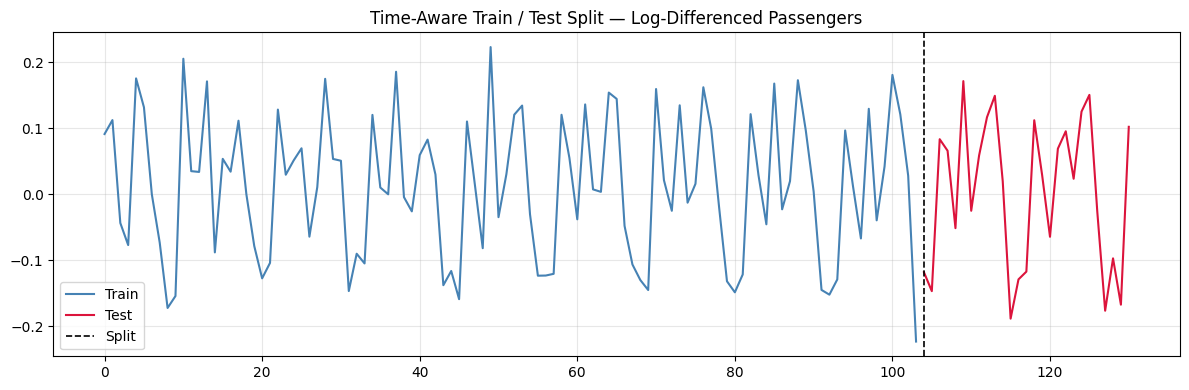

In [ ]:
# ── SOLUTION: Time-aware split ──────────────────────────────────────────────
N_LAGS     = 12
TRAIN_FRAC = 0.80

X, y = make_lag_matrix(series, N_LAGS)
split = int(len(X) * TRAIN_FRAC)           # SOLUTION

X_train, X_test = X[:split], X[split:]     # SOLUTION
y_train, y_test = y[:split], y[split:]     # SOLUTION

print(f'Training samples : {len(X_train)}')
print(f'Test samples     : {len(X_test)}')

# Visualise the split on the original (log-diff) series
fig, ax = plt.subplots()
train_idx = np.arange(split)
test_idx  = np.arange(split, len(y))
ax.plot(train_idx, y_train, label='Train', color='steelblue')
ax.plot(test_idx,  y_test,  label='Test',  color='crimson')
ax.axvline(split, color='black', linestyle='--', linewidth=1.2, label='Split')
ax.set_title('Time-Aware Train / Test Split — Log-Differenced Passengers')
ax.legend()
plt.tight_layout()
plt.show()

### ✅ MODEL ANSWER — Coding Practice


```python
def train_test_time(X, y, TRAIN_FRAC):
    """
    Chronologically splits (lag-embedded feature matrix) X, y time series data

    Parameters
    ----------
    X : lag-embedded feature matrix
    y :

    Returns
    -------
    X_train : np.ndarray, shape (T - n_lags, n_lags)
    X_test  :
    y_train :
    y_test  : np.ndarray, shape (T - n_lags,)
    """

    split = int(len(X) * TRAIN_FRAC)           # SOLUTION

    X_train, X_test = X[:split], X[split:]     # SOLUTION
    y_train, y_test = y[:split], y[split:]     # SOLUTION

    print(f'Training samples : {len(X_train)}')
    print(f'Test samples     : {len(X_test)}')

    return X_train, X_test, y_train, y_test
```

---
## 📣 Segment 2 — Naive Baseline & AR Model (30 min)

### Why Start with a Baseline?

Every model evaluation needs a **baseline** — the simplest possible forecast. If a
sophisticated model can't beat a naive baseline, it provides no value. The **naive
last-value forecast** (also called the *persistence* or *random walk* forecast) predicts
that the next value equals the last observed value:

$$\hat{x}_{t+1} = x_t$$

For a stationary series this is often surprisingly hard to beat.

### AR Model Connection

The AR model from Day 2 is the natural next step. We use `AutoReg` with `lags=12` on the
training set and generate one-step-ahead predictions on the test set using `.predict()`.

### ⚠️ Common Mistakes
- **Naive baseline index confusion:** The naive forecast for test point $i$ is the *last
  training value* (for 1-step ahead) or `y_test[i-1]` for multi-step. Be precise.
- **AutoReg predict range:** `result.predict(start, end)` uses the *original series*
  indexing, not the lag matrix indexing. This trips many students. Show the offset.
- **Forgetting to refit on training data only:** Students sometimes reuse the Day 2
  model fitted on the full series. The model must be fitted *only* on training data.

In [ ]:
# ── SOLUTION: Naive last-value baseline ────────────────────────────────────
# For each test point, predict the value of the immediately preceding observation
naive_preds = np.concatenate([[y_train[-1]], y_test[:-1]])  # SOLUTION

print('Naive baseline predictions (first 5):', naive_preds[:5])
print('Actual test values        (first 5):', y_test[:5])

Naive baseline predictions (first 5): [-0.22314355 -0.11809249 -0.14675009  0.08351063  0.0660211 ]
Actual test values        (first 5): [-0.11809249 -0.14675009  0.08351063  0.0660211  -0.05129329]


In [ ]:
# ── SOLUTION: AR model on training data ────────────────────────────────────
# Fit AutoReg on the training portion of the original series
train_series = series[:split + N_LAGS]   # include the burn-in lags

ar_model  = AutoReg(train_series, lags=N_LAGS)
ar_result = ar_model.fit()

# Predict the test window
ar_start = len(train_series)
ar_end   = ar_start + len(y_test) - 1
ar_preds = ar_result.predict(start=ar_start, end=ar_end, dynamic=False)

print('AR predictions (first 5):   ', ar_preds[:5])
print('Actual test values (first 5):', y_test[:5])

AR predictions (first 5):    [-0.11796544 -0.08719819  0.10486478  0.0274176  -0.06260433]
Actual test values (first 5): [-0.11809249 -0.14675009  0.08351063  0.0660211  -0.05129329]


> 🗣️ **Instructor note:** `dynamic=False` means the model uses *actual* lagged values
> from the series at each step (not its own previous predictions). For 1-step-ahead
> evaluation this is correct. For multi-step-ahead, `dynamic=True` would chain predictions.